In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

In [3]:
from google.colab import files
uploaded = files.upload()

Saving produce.csv to produce.csv


In [4]:
df = pd.read_csv('produce.csv')
print(df.shape)
df.head()

(429, 25)


,Particulars,Frequency,Unit,3-1993,3-1994,3-1995,3-1996,3-1997,3-1998,3-1999,...,3-2005,3-2006,3-2007,3-2008,3-2009,3-2010,3-2011,3-2012,3-2013,3-2014
0,Agricultural Production Foodgrains,"Annual, Ending mar Of Each Year",Ton mn,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,198.36282,208.6016,217.28212,230.77504,234.466177,218.107372,244.491809,259.286253,257.13,264.3806
1,Agricultural Production Foodgrains Kharif,"Annual, Ending mar Of Each Year",Ton mn,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,103.30942,109.8734,110.57622,120.95724,118.138577,103.954032,120.853191,131.274812,128.07,129.3686
2,Agricultural Production Foodgrains Rabi,"Annual, Ending mar Of Each Year",Ton mn,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,95.05340,98.7282,106.70590,109.81780,116.327600,114.153340,123.638618,128.011441,129.06,135.0120
3,Agricultural Production Foodgrains Rice,"Annual, Ending mar Of Each Year",Ton mn,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,83.13170,91.7934,93.35530,96.69290,99.182500,89.092901,95.979819,105.301100,105.24,106.2872
4,Agricultural Production Foodgrains Rice Kharif,"Annual, Ending mar Of Each Year",Ton mn,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,72.23000,78.2719,80.17080,82.65940,84.908200,75.916510,80.651241,92.780700,92.37,92.0093


In [5]:
df.columns = df.columns.str.strip()
print(df.columns.tolist())

['Particulars', 'Frequency', 'Unit', '3-1993', '3-1994', '3-1995', '3-1996', '3-1997', '3-1998', '3-1999', '3-2000', '3-2001', '3-2002', '3-2003', '3-2004', '3-2005', '3-2006', '3-2007', '3-2008', '3-2009', '3-2010', '3-2011', '3-2012', '3-2013', '3-2014']


In [6]:
df_melted = pd.melt(df, id_vars=['Particulars','Frequency','Unit'],
                     var_name='Year', value_name='Production')
df_melted.head()

,Particulars,Frequency,Unit,Year,Production
0,Agricultural Production Foodgrains,"Annual, Ending mar Of Each Year",Ton mn,3-1993,NaN
1,Agricultural Production Foodgrains Kharif,"Annual, Ending mar Of Each Year",Ton mn,3-1993,NaN
2,Agricultural Production Foodgrains Rabi,"Annual, Ending mar Of Each Year",Ton mn,3-1993,NaN
3,Agricultural Production Foodgrains Rice,"Annual, Ending mar Of Each Year",Ton mn,3-1993,NaN
4,Agricultural Production Foodgrains Rice Kharif,"Annual, Ending mar Of Each Year",Ton mn,3-1993,NaN


In [7]:
df_melted['Year'] = df_melted['Year'].str.extract(r'(\d{4})').astype(int)

In [8]:
df_melted['Production'] = pd.to_numeric(df_melted['Production'], errors='coerce')
df_melted = df_melted.dropna(subset=['Production'])
df_melted.reset_index(drop=True, inplace=True)
print(df_melted.shape)
df_melted.head()

(4272, 5)


,Particulars,Frequency,Unit,Year,Production
0,Agricultural Production Foodgrains Wheat Volum...,"Annual, Ending mar Of Each Year",Ton th,1993,0.0
1,Agricultural Production Foodgrains Wheat Volum...,"Annual, Ending mar Of Each Year",Ton th,1993,0.0
2,Agricultural Production Foodgrains Wheat Volum...,"Annual, Ending mar Of Each Year",Ton th,1993,0.0
3,Agricultural Production Foodgrains Wheat Volum...,"Annual, Ending mar Of Each Year",Ton th,1994,0.0
4,Agricultural Production Foodgrains Wheat Volum...,"Annual, Ending mar Of Each Year",Ton th,1994,0.0


In [9]:
le = LabelEncoder()
df_melted['Particulars'] = le.fit_transform(df_melted['Particulars'])
df_melted['Frequency'] = le.fit_transform(df_melted['Frequency'])
df_melted['Unit'] = le.fit_transform(df_melted['Unit'])
df_melted.head()

,Particulars,Frequency,Unit,Year,Production
0,231,0,3,1993,0.0
1,238,0,3,1993,0.0
2,243,0,3,1993,0.0
3,231,0,3,1994,0.0
4,238,0,3,1994,0.0


In [10]:
X = df_melted.drop('Production', axis=1)
y = df_melted['Production']
print(X.shape, y.shape)

(4272, 4) (4272,)


In [11]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print(X_train.shape, X_test.shape)

(3417, 4) (855, 4)


In [12]:
model = RandomForestRegressor(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

RandomForestRegressor(random_state=42)

In [13]:
y_pred = model.predict(X_test)

In [14]:
print("R2 Score:", r2_score(y_test, y_pred))
print("MAE:", mean_absolute_error(y_test, y_pred))
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred)))

R2 Score: 0.9625219883469593
MAE: 130.830764823179
RMSE: 390.1123927945718


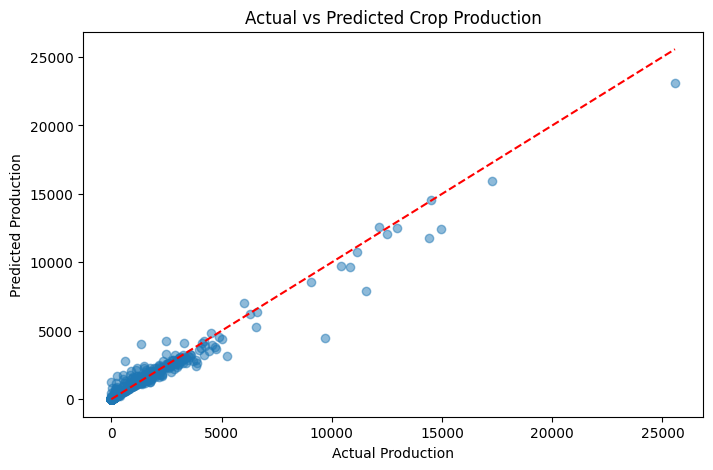

In [15]:
plt.figure(figsize=(8,5))
plt.scatter(y_test, y_pred, alpha=0.5)
plt.xlabel("Actual Production")
plt.ylabel("Predicted Production")
plt.title("Actual vs Predicted Crop Production")
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
plt.show()